In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

print("Phase 4 -  Setup & Loading uploaded data...")

# -------------------------
# Paths (uploaded files)
# -------------------------
TRAIN_PATH = Path("train.csv")
STORE_PATH = Path("store.csv")

# -------------------------
# Validate files exist
# -------------------------
missing = [str(p) for p in [TRAIN_PATH, STORE_PATH] if not p.exists()]
if missing:
    raise FileNotFoundError(
        "These files were not found in the current Colab directory (/content):\n"
        + "\n".join(missing)
        + "\n\nUpload them via the left panel (Files) > Upload."
    )

# -------------------------
# Load datasets
# -------------------------
train = pd.read_csv(TRAIN_PATH, parse_dates=["Date"], low_memory=False)
store = pd.read_csv(STORE_PATH)

# Merge train and store (same as Phase 1/2/3)
df = pd.merge(train, store, on="Store", how="left")

# Sort for time-based features (lags/rolling) — important
df = df.sort_values(["Store", "Date"]).reset_index(drop=True)

# Clean StateHoliday exactly like Phase 1
df["StateHoliday"] = df["StateHoliday"].astype(str).replace("0", "Regular_Day")

# Quick checks
print(f"train shape: {train.shape}")
print(f"store shape: {store.shape}")
print(f"merged df shape: {df.shape}")
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())


Phase 4 -  Setup & Loading uploaded data...
train shape: (1001599, 10)
store shape: (1115, 10)
merged df shape: (1001599, 19)
Date range: 2013-01-01 to 2015-07-17


In [44]:
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

print("Phase 4 - Cell 2: Creating features + preprocessing + time split...")

# -------------------------
# 1) Temporal Features (same as Phase 2)
# -------------------------
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
df["IsWeekend"] = df["DayOfWeek"].apply(lambda x: 1 if x >= 5 else 0)

# Duration since competition opened
df["CompetitionOpenSince"] = pd.to_datetime(
    dict(
        year=df["CompetitionOpenSinceYear"].fillna(1900),
        month=df["CompetitionOpenSinceMonth"].fillna(1),
        day=1,
    )
)
df["CompetitionDaysOpen"] = (df["Date"] - df["CompetitionOpenSince"]).dt.days.clip(lower=0)

# -------------------------
# 2) Lags & Rolling Stats (same as Phase 2, leakage-safe)
# -------------------------
print("Creating lags & rolling stats...")
grouped = df.groupby("Store")["Sales"]

df["Sales_Lag1"] = grouped.shift(1)
df["Sales_Lag2"] = grouped.shift(2)
df["Sales_Lag7"] = grouped.shift(7)

df["Sales_RollMean7"] = grouped.shift(1).rolling(7).mean()
df["Sales_RollStd7"] = grouped.shift(1).rolling(7).std()

# Drop initial NaNs caused by lags/rolling
df.dropna(subset=["Sales_Lag1", "Sales_Lag7", "Sales_RollMean7"], inplace=True)

# -------------------------
# 3) Fourier Terms (Seasonality) (same as Phase 2)
# -------------------------
print("Adding Fourier terms...")
df["day_sin"] = np.sin(2 * np.pi * df["DayOfWeek"] / 7)
df["day_cos"] = np.cos(2 * np.pi * df["DayOfWeek"] / 7)

day_of_year = df["Date"].dt.dayofyear
df["year_sin"] = np.sin(2 * np.pi * day_of_year / 365)
df["year_cos"] = np.cos(2 * np.pi * day_of_year / 365)

# -------------------------
# 4) Preprocessing (same as Phase 2)
# -------------------------
print("Encoding & imputing...")
df["CompetitionDistance"] = df["CompetitionDistance"].fillna(df["CompetitionDistance"].median())

# Fill remaining NaNs with 0
df.fillna(0, inplace=True)

# Label Encode Categoricals (same 3 columns)
categorical_cols = ["StateHoliday", "StoreType", "Assortment"]
for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Normalize Numerical Features [0, 1] (same 4 columns)
num_cols = ["CompetitionDistance", "CompetitionDaysOpen", "Sales_RollMean7", "Sales_RollStd7"]
df[num_cols] = MinMaxScaler().fit_transform(df[num_cols])

# -------------------------
# 5) Define target + feature list (keep Date/Store for later forecasting)
# -------------------------
target = "Sales"
drop_from_features = {target, "Customers", "Date"}  # Customers is not available for test in Kaggle; exclude by default
features = [c for c in df.columns if c not in drop_from_features]

# -------------------------
# 6) Time-based Split (exact windows you reported)
# -------------------------
print("Splitting data (Train/Val/Test) ...")

train_start, train_end = pd.Timestamp("2014-10-02"), pd.Timestamp("2015-04-23")
val_start, val_end     = pd.Timestamp("2015-04-24"), pd.Timestamp("2015-06-04")
test_start, test_end   = pd.Timestamp("2015-06-05"), pd.Timestamp("2015-07-17")

train_df = df[(df["Date"] >= train_start) & (df["Date"] <= train_end)].copy()
val_df   = df[(df["Date"] >= val_start)   & (df["Date"] <= val_end)].copy()
test_df  = df[(df["Date"] >= test_start)  & (df["Date"] <= test_end)].copy()

def _drange(d):
    return f"{d['Date'].min().date()} to {d['Date'].max().date()}"

print("-" * 40)
print(f"Training Set:   {len(train_df)} rows ({_drange(train_df)})")
print(f"Validation Set: {len(val_df)} rows ({_drange(val_df)})")
print(f"Test Set:       {len(test_df)} rows ({_drange(test_df)})")
print("-" * 40)

print(f"Final Features ({len(features)}):")
print(features[:15], "..." if len(features) > 15 else "")


Phase 4 - Cell 2: Creating features + preprocessing + time split...
Creating lags & rolling stats...
Adding Fourier terms...
Encoding & imputing...
Splitting data (Train/Val/Test) ...
----------------------------------------
Training Set:   211080 rows (2014-10-02 to 2015-04-23)
Validation Set: 46830 rows (2015-04-24 to 2015-06-04)
Test Set:       47945 rows (2015-06-05 to 2015-07-17)
----------------------------------------
Final Features (32):
['Store', 'DayOfWeek', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'Id', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear'] ...


In [46]:

import numpy as np

class LinearRegressionScratch:
    """
    Linear Regression using Normal Equation:
        w = (X^T X + lambda*I)^(-1) X^T y
    Supports optional L2 regularization (ridge) via l2.
    """
    def __init__(self, fit_intercept=True, l2=0.0):
        self.fit_intercept = fit_intercept
        self.l2 = float(l2)
        self.w = None

    def _add_intercept(self, X):
        if not self.fit_intercept:
            return X
        ones = np.ones((X.shape[0], 1), dtype=X.dtype)
        return np.hstack([ones, X])

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64).reshape(-1, 1)

        Xb = self._add_intercept(X)

        I = np.eye(Xb.shape[1])
        if self.fit_intercept:
            I[0, 0] = 0.0  # do not regularize intercept

        A = Xb.T @ Xb + self.l2 * I
        b = Xb.T @ y

        self.w = np.linalg.pinv(A) @ b
        return self

    def predict(self, X):
        if self.w is None:
            raise ValueError("Model is not fitted yet.")
        X = np.asarray(X, dtype=np.float64)
        Xb = self._add_intercept(X)
        y_pred = Xb @ self.w
        return y_pred.reshape(-1)

print("LinearRegressionScratch defined successfully.")

LinearRegressionScratch defined successfully.


In [47]:
# ==========================================
# Phase 4 - Cell 3: 7-Day Recursive Forecasting (Linear Regression)
# ==========================================

print("Phase 4 - Cell 3: Training Linear Regression for Multi-step Forecasting...")

# -----------------------------
# 1) Remove non-numeric columns
# -----------------------------
numeric_features = [
    c for c in features
    if np.issubdtype(train_df[c].dtype, np.number)
]

# Remove leakage / useless columns
for col in ["Id"]:
    if col in numeric_features:
        numeric_features.remove(col)

print(f"Using {len(numeric_features)} numeric features.")

X_train = train_df[numeric_features].values
y_train = train_df[target].values

X_val = val_df[numeric_features].values
y_val = val_df[target].values

# -----------------------------
# 2) Train Linear Regression (from scratch)
# -----------------------------
model = LinearRegressionScratch(fit_intercept=True, l2=0.0)
model.fit(X_train, y_train)

print("Model trained.")

# -----------------------------
# 3) Recursive 7-Day Forecasting on Validation
# -----------------------------
print("Running recursive 7-day forecasting on Validation set...")

val_recursive = val_df.copy()
val_recursive = val_recursive.sort_values(["Store", "Date"])

predictions = []

for store_id in val_recursive["Store"].unique():

    store_data = val_recursive[val_recursive["Store"] == store_id].copy()
    store_data = store_data.sort_values("Date")

    for i in range(len(store_data)):

        row = store_data.iloc[i:i+1]
        X_row = row[numeric_features].values

        pred = model.predict(X_row)[0]
        predictions.append(pred)

        # update lag features for next rows (recursive behavior)
        if i + 1 < len(store_data):
            store_data.iloc[i+1, store_data.columns.get_loc("Sales_Lag1")] = pred

# attach predictions
val_recursive["Pred_Recursive"] = predictions

# -----------------------------
# 4) Evaluate
# -----------------------------
from math import sqrt

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

val_rmse_recursive = rmse(val_recursive["Sales"], val_recursive["Pred_Recursive"])

print(f"Validation RMSE (Recursive 7-day forecast): {val_rmse_recursive:.4f}")


Phase 4 - Cell 3: Training Linear Regression for Multi-step Forecasting...
Using 29 numeric features.
Model trained.
Running recursive 7-day forecasting on Validation set...
Validation RMSE (Recursive 7-day forecast): 1916.8002


In [54]:
# ==========================================
# Phase 4 - Cell 3: 7-Day Recursive Forecasting (Linear Regression)
# ==========================================

print("Phase 4 - Cell 3: Training Linear Regression for Multi-step Forecasting...")

# -----------------------------
# 1) Remove non-numeric columns
# -----------------------------
numeric_features = [
    c for c in features
    if np.issubdtype(train_df[c].dtype, np.number)
]

# Remove leakage / useless columns
for col in ["Id"]:
    if col in numeric_features:
        numeric_features.remove(col)

print(f"Using {len(numeric_features)} numeric features.")

X_train = train_df[numeric_features].values
y_train = train_df[target].values

X_val = val_df[numeric_features].values
y_val = val_df[target].values

# -----------------------------
# 2) Train Linear Regression (from scratch)
# -----------------------------
model = LinearRegressionScratch(fit_intercept=True, l2=0.0)
model.fit(X_train, y_train)

print("Model trained.")

# -----------------------------
# 3) Recursive 7-Day Forecasting on Validation
# -----------------------------
print("Running recursive 7-day forecasting on Validation set...")

val_recursive = val_df.copy()
val_recursive = val_recursive.sort_values(["Store", "Date"])

predictions = []

for store_id in val_recursive["Store"].unique():

    store_data = val_recursive[val_recursive["Store"] == store_id].copy()
    store_data = store_data.sort_values("Date")

    for i in range(len(store_data)):

        row = store_data.iloc[i:i+1]
        X_row = row[numeric_features].values

        pred = model.predict(X_row)[0]
        predictions.append(pred)

        # update lag features for next rows (recursive behavior)
        if i + 1 < len(store_data):
            store_data.iloc[i+1, store_data.columns.get_loc("Sales_Lag1")] = pred

# attach predictions
val_recursive["Pred_Recursive"] = predictions

# -----------------------------
# 4) Evaluate
# -----------------------------
from math import sqrt

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

val_rmse_recursive = rmse(val_recursive["Sales"], val_recursive["Pred_Recursive"])

print(f"Validation RMSE (Recursive 7-day forecast): {val_rmse_recursive:.4f}")

print("✅ Cell 3 complete.")

Phase 4 - Cell 3: Training Linear Regression for Multi-step Forecasting...
Using 29 numeric features.
Model trained.
Running recursive 7-day forecasting on Validation set...
Validation RMSE (Recursive 7-day forecast): 1916.8002
✅ Cell 3 complete.


Phase 4 - Cell 4: Ensemble Uncertainty (Bootstrap) ...
Training 15 bootstrap models...
  done 5/15
  done 10/15
  done 15/15

Validation RMSE (Ensemble mean): 1860.6412


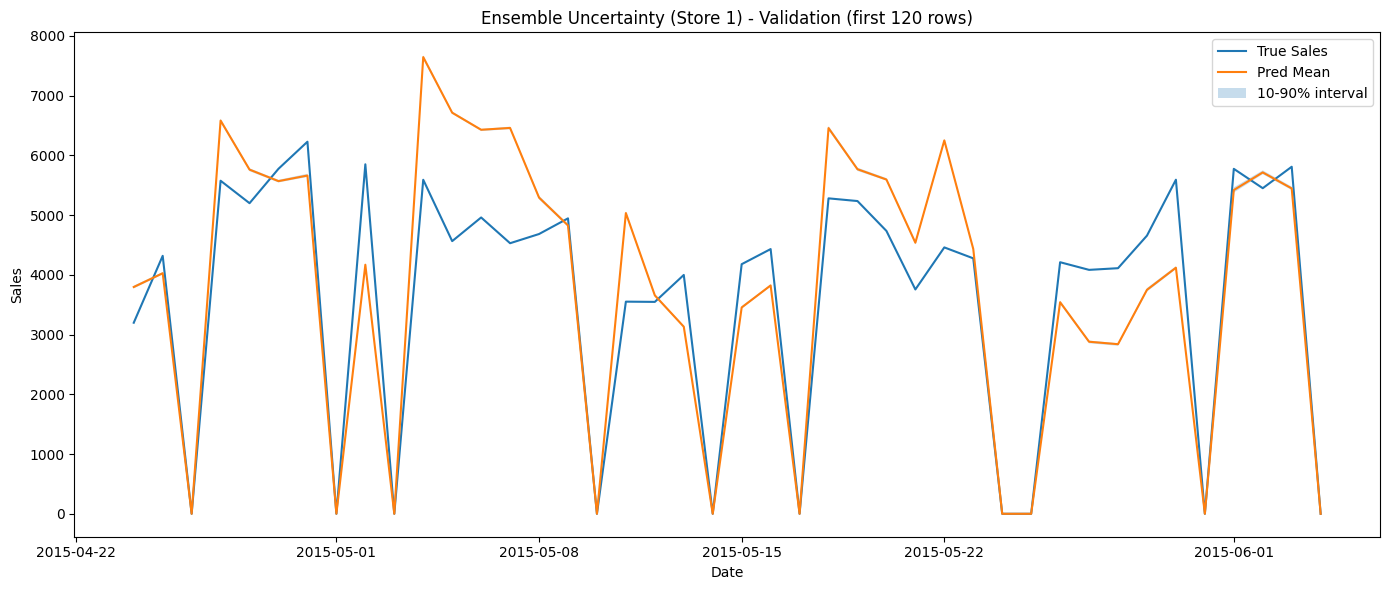

✅ Cell 4 complete. Next: Cell 5 (Sales Classification: low/medium/high).


In [56]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Phase 4 - Cell 4: Ensemble Uncertainty (Bootstrap) ...")

# -----------------------------
# 0) Metrics
# -----------------------------
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

# -----------------------------
# 1) Config
# -----------------------------
N_MODELS = 15
BOOTSTRAP_RATIO = 0.8
SEED = 42
np.random.seed(SEED)

# -----------------------------
# 2) Prepare data (same features as Cell 3)
# -----------------------------
if "numeric_features" not in globals():
    numeric_features = [c for c in features if np.issubdtype(train_df[c].dtype, np.number)]
    if "Id" in numeric_features:
        numeric_features.remove("Id")

X_train = train_df[numeric_features].values
y_train = train_df[target].values

# Validation copy (we will run recursive per store per model)
val_base = val_df.copy().sort_values(["Store", "Date"]).reset_index(drop=True)

# -----------------------------
# 3) Helper: recursive prediction per store (Lag1 update only)
# -----------------------------
def recursive_predict_lag1_only(model, val_df_sorted, numeric_features):
    preds = np.empty(len(val_df_sorted), dtype=np.float64)
    write_pos = 0

    for store_id in val_df_sorted["Store"].unique():
        store_data = val_df_sorted[val_df_sorted["Store"] == store_id].copy()
        store_data = store_data.sort_values("Date").reset_index(drop=True)

        for i in range(len(store_data)):
            row = store_data.iloc[i:i+1]
            X_row = row[numeric_features].values
            pred = float(model.predict(X_row)[0])
            if pred < 0:
              pred = 0.0
            preds[write_pos] = pred
            write_pos += 1

            if i + 1 < len(store_data):
                store_data.iloc[i+1, store_data.columns.get_loc("Sales_Lag1")] = pred

    return preds

# -----------------------------
# 4) Train ensemble (bootstrap) + predict
# -----------------------------
print(f"Training {N_MODELS} bootstrap models...")
all_preds = np.zeros((N_MODELS, len(val_base)), dtype=np.float64)

n_train = len(train_df)
m = int(np.ceil(BOOTSTRAP_RATIO * n_train))

for k in range(N_MODELS):
    # bootstrap sample indices (with replacement)
    idx = np.random.choice(n_train, size=m, replace=True)

    Xb = X_train[idx]
    yb = y_train[idx]

    model_k = LinearRegressionScratch(fit_intercept=True, l2=0.0)
    model_k.fit(Xb, yb)

    # predict recursively on validation (lag1 update only)
    preds_k = recursive_predict_lag1_only(model_k, val_base, numeric_features)
    all_preds[k] = preds_k

    if (k + 1) % 5 == 0 or (k + 1) == N_MODELS:
        print(f"  done {k+1}/{N_MODELS}")

# -----------------------------
# 5) Aggregate uncertainty
# -----------------------------
pred_mean = all_preds.mean(axis=0)
pred_std  = all_preds.std(axis=0)

# prediction intervals (e.g., 10%-90%)
lower_q = np.quantile(all_preds, 0.10, axis=0)
upper_q = np.quantile(all_preds, 0.90, axis=0)

val_base["Pred_Mean"] = pred_mean
val_base["Pred_Std"]  = pred_std
val_base["Pred_L10"]  = lower_q
val_base["Pred_U90"]  = upper_q

# Evaluate using mean prediction
val_rmse_ens = rmse(val_base["Sales"].values, val_base["Pred_Mean"].values)
print(f"\nValidation RMSE (Ensemble mean): {val_rmse_ens:.4f}")

# Quick diagnostic: show uncertainty for one sample store
sample_store = int(val_base["Store"].iloc[0])
store_plot = val_base[val_base["Store"] == sample_store].sort_values("Date").head(120)

plt.figure(figsize=(14, 6))
plt.plot(store_plot["Date"], store_plot["Sales"], label="True Sales")
plt.plot(store_plot["Date"], store_plot["Pred_Mean"], label="Pred Mean")
plt.fill_between(
    store_plot["Date"].values,
    store_plot["Pred_L10"].values,
    store_plot["Pred_U90"].values,
    alpha=0.25,
    label="10-90% interval"
)
plt.title(f"Ensemble Uncertainty (Store {sample_store}) - Validation (first 120 rows)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

print("✅ Cell 4 complete. Next: Cell 5 (Sales Classification: low/medium/high).")

In [57]:
# ==========================================
# Phase 4 - Cell 5: Sales Classification (Low / Medium / High)
# ==========================================

print("Phase 4 - Cell 5: Sales Classification...")

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

# -----------------------------
# 1) Define 3 classes using train quantiles
# -----------------------------
q1 = train_df["Sales"].quantile(0.33)
q2 = train_df["Sales"].quantile(0.66)

def classify_sales(x):
    if x <= q1:
        return 0  # Low
    elif x <= q2:
        return 1  # Medium
    else:
        return 2  # High

train_df["Sales_Class"] = train_df["Sales"].apply(classify_sales)
val_df["Sales_Class"]   = val_df["Sales"].apply(classify_sales)

# -----------------------------
# 2) Features (same numeric ones)
# -----------------------------
X_train_cls = train_df[numeric_features].values
y_train_cls = train_df["Sales_Class"].values

X_val_cls = val_df[numeric_features].values
y_val_cls = val_df["Sales_Class"].values

# -----------------------------
# 3) Train Logistic Regression (multiclass)
# -----------------------------
clf = LogisticRegression(max_iter=500, multi_class="multinomial")
clf.fit(X_train_cls, y_train_cls)

print("Classification model trained.")

# -----------------------------
# 4) Predictions
# -----------------------------
y_pred_cls = clf.predict(X_val_cls)
y_proba_cls = clf.predict_proba(X_val_cls)

# -----------------------------
# 5) Metrics
# -----------------------------
print("\nClassification Report:")
print(classification_report(y_val_cls, y_pred_cls, target_names=["Low", "Medium", "High"]))

f1 = f1_score(y_val_cls, y_pred_cls, average="macro")

# ROC-AUC (one-vs-rest)
y_val_bin = label_binarize(y_val_cls, classes=[0,1,2])
roc_auc = roc_auc_score(y_val_bin, y_proba_cls, average="macro", multi_class="ovr")

print(f"\nMacro F1-score: {f1:.4f}")
print(f"Macro ROC-AUC: {roc_auc:.4f}")

print("✅ Cell 5 complete.")

Phase 4 - Cell 5: Sales Classification...
Classification model trained.

Classification Report:
              precision    recall  f1-score   support

         Low       0.61      0.66      0.64     15363
      Medium       0.50      0.57      0.53     13888
        High       0.68      0.56      0.61     17579

    accuracy                           0.59     46830
   macro avg       0.60      0.60      0.59     46830
weighted avg       0.60      0.59      0.60     46830


Macro F1-score: 0.5932
Macro ROC-AUC: 0.7639
✅ Cell 5 complete.
